In [112]:
import numpy as np
import pandas as pd

In [113]:
data='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
!wget $data

--2026-09-21 11:03:56--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv


Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv.3’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.007s  

2026-09-21 11:03:56 (82.1 MB/s) - ‘car_fuel_efficiency_2026.csv.3’ saved [635180/635180]



In [114]:
df = pd.read_csv(data)

In [115]:
df.columns=df.columns.str.replace(' ','_').str.lower()

In [116]:
columns = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [117]:
df = df[columns]

In [118]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [119]:
df['horsepower'].median()

np.float64(254.0)

In [120]:
n=len(df)
n_val=int(n*0.2)
n_test=int(n*0.2)
n_train=n-n_val-n_test

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

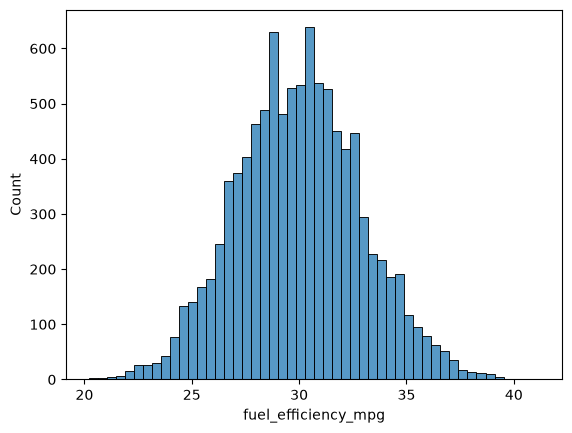

In [122]:
sns.histplot(data = df[df.fuel_efficiency_mpg > 20], x = 'fuel_efficiency_mpg', bins = 50)

In [123]:
np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

In [124]:
df_train=df.iloc[idx[:n_train]]
df_val=df.iloc[idx[n_train:n_train + n_val]]
df_test=df.iloc[idx[n_train + n_val:]]


In [125]:
df_train=df_train.reset_index(drop=True)
df_val=df_val.reset_index(drop=True)
df_test=df_test.reset_index(drop=True)

In [126]:
y_train=np.log1p(df_train.fuel_efficiency_mpg.values)
y_val=np.log1p(df_val.fuel_efficiency_mpg.values)
y_test=np.log1p(df_test.fuel_efficiency_mpg.values)

In [127]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [128]:
def prepare_X(df, fill_value):
    df = df.copy()
    # features = base.copy()
    X = df.fillna(fill_value).values
    return X

In [129]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
     
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
     
    return w_full[0], w_full[1:]

In [130]:
X_train_0 = prepare_X(df_train, 0)
w0_0, w_0 = train_linear_regression(X_train_0, y_train)

In [131]:
X_val_0 = prepare_X(df_val, 0)
y_pred_0 = w0_0 + X_val_0.dot(w_0)
rmse_0 = np.sqrt(((y_val - y_pred_0) ** 2).mean())

In [132]:
mean_horsepower = df_train['horsepower'].mean()
mean_horsepower

np.float64(254.46338337605272)

In [133]:
X_train_m = prepare_X(df_train, mean_horsepower)
w0_m, w_m = train_linear_regression(X_train_m, y_train)

X_val_m = prepare_X(df_val, mean_horsepower)
y_pred_m = w0_m + X_val_m.dot(w_m)
rmse_m = np.sqrt(((y_val - y_pred_m) ** 2).mean())

In [134]:
# print(f"Fill with 0: {rmse_0}")
# print(f"Fill with mean: {rmse_m}")
print(f"Fill with 0: {round(rmse_0, 3)}")
print(f"Fill with mean: {round(rmse_m, 3)}")

Fill with 0: 0.071
Fill with mean: 0.071


In [135]:
def train_linear_regression_reg(X, y, r=0.01):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
     
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
     
    return w_full[0], w_full[1:]

In [136]:
X_train = prepare_X(df_train, 0)
X_val = prepare_X(df_val, 0)
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]

for r in r_values:
    # X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    # X_val = prepare_X(df_val, 0)
    y_pred = w0 + X_val.dot(w)
    score = np.sqrt(((y_val - y_pred) ** 2).mean())
    print(f"r = {r:<8} | RMSE = {round(score, 4)}")

r = 0        | RMSE = 0.0715
r = 0.01     | RMSE = 0.0715
r = 0.1      | RMSE = 0.0717
r = 1        | RMSE = 0.0727
r = 5        | RMSE = 0.0733
r = 10       | RMSE = 0.0734
r = 100      | RMSE = 0.0735


In [ ]:
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
n = len(df)
rmse_arr=[]

for s in seed:
    idx = np.arange(n)
    np.random.seed(s)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    
    y_train=df_train.fuel_efficiency_mpg.values
    y_val=df_val.fuel_efficiency_mpg.values
    
    df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
    df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
    
    X_train = prepare_X(df_train, 0)
    X_val = prepare_X(df_val, 0)

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    
    rmse = np.sqrt(((y_val - y_pred) ** 2).mean())

    rmse_arr.append(rmse)
    
print(round(np.std(rmse_arr),3))

0.029


In [152]:
seed = 9
n = len(df)
r = 0.001

idx = np.arange(n)
np.random.seed(seed)
np.random.shuffle(idx)
    
df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
df_test = df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values
    
df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])
df_test = df_test.drop(columns=['fuel_efficiency_mpg'])

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)

y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train, 0)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=r)

X_test = prepare_X(df_test, 0)

y_pred = w0 + X_test.dot(w)
    
rmse = np.sqrt(((y_test - y_pred) ** 2).mean())

print(round(rmse, 3))

2.236


<Axes: ylabel='Count'>

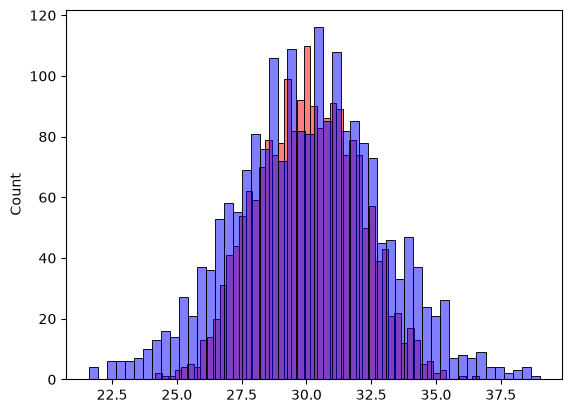

In [150]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_val, color='blue', alpha=0.5, bins=50)